# 🏥 Notebook 2 — Benchmarking Inférence : CPU vs GPU
**Projet P8 — Détection rapide d'anomalies (images médicales)**

Ce notebook mesure la **vitesse d'inférence** (prédiction) selon :
- Le device (CPU vs GPU)
- La taille du batch (1, 8, 16, 32, 64 images)
- Le débit (images/seconde)

> ⚠️ Activer GPU : `Exécution > Modifier le type d'exécution > GPU (T4)`

In [ ]:
!pip install -q torch torchvision matplotlib seaborn pandas

## ⚙️ 1. Setup — Modèle & devices

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

# Vérification GPU
print('PyTorch version :', torch.__version__)
print('CUDA disponible  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU              :', torch.cuda.get_device_name(0))
    print('Mémoire GPU      :', f'{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Charger ResNet18 (poids pré-entraînés)
def load_model(device):
    m = models.resnet18(pretrained=True)
    m.fc = nn.Linear(m.fc.in_features, 2)
    m.eval()
    return m.to(device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

print('\n✅ Modèle prêt')

PyTorch version : 2.11.0+cu128
CUDA disponible  : True
GPU              : Tesla T4
Mémoire GPU      : 15.6 GB

✅ Modèle prêt


## 🔬 2. Fonction de benchmark inférence

In [ ]:
def benchmark_inference(device_name, batch_sizes, n_runs=50):
    """
    Mesure le temps d'inférence moyen pour différentes tailles de batch.
    n_runs : nombre de répétitions pour avoir une mesure stable
    """
    device = torch.device(device_name)
    model  = load_model(device)
    results = []

    print(f'\n{'='*55}')
    print(f'⚡ Benchmark inférence — {device_name.upper()}')
    print(f'{'='*55}')
    print(f'  {'Batch':>8} | {'Temps moy (ms)':>16} | {'Images/sec':>12} | {'Latence/img (ms)':>18}')
    print(f'  {"-"*8}-+-{"-"*16}-+-{"-"*12}-+-{"-"*18}')

    for bs in batch_sizes:
        # Créer un batch de tenseurs aléatoires (simule des radiographies)
        dummy = torch.randn(bs, 3, 224, 224).to(device)

        # Warmup (GPU a besoin de quelques passes pour être stable)
        with torch.no_grad():
            for _ in range(5):
                _ = model(dummy)
        if device_name == 'cuda':
            torch.cuda.synchronize()

        # Mesure
        times = []
        with torch.no_grad():
            for _ in range(n_runs):
                t0 = time.perf_counter()
                _ = model(dummy)
                if device_name == 'cuda':
                    torch.cuda.synchronize()
                times.append((time.perf_counter() - t0) * 1000)

        avg_ms      = np.mean(times)
        std_ms      = np.std(times)
        throughput  = (bs * 1000) / avg_ms
        latency_img = avg_ms / bs

        results.append({
            'device': device_name, 'batch_size': bs,
            'avg_ms': avg_ms, 'std_ms': std_ms,
            'throughput': throughput, 'latency_per_img': latency_img
        })
        print(f'  {bs:>8} | {avg_ms:>13.2f}ms | {throughput:>11.0f} | {latency_img:>15.2f}ms')

    return pd.DataFrame(results)

BATCH_SIZES = [1, 4, 8, 16, 32, 64]
print('✅ Fonction prête')

✅ Fonction prête


## 🖥️ 3. Benchmark CPU

In [ ]:
df_cpu = benchmark_inference('cpu', BATCH_SIZES, n_runs=20)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]



⚡ Benchmark inférence — CPU
     Batch |   Temps moy (ms) |   Images/sec |   Latence/img (ms)
  ---------+------------------+--------------+-------------------
         1 |         58.28ms |          17 |           58.28ms
         4 |        212.85ms |          19 |           53.21ms
         8 |        403.80ms |          20 |           50.47ms
        16 |        944.63ms |          17 |           59.04ms
        32 |       1807.68ms |          18 |           56.49ms
        64 |       3869.32ms |          17 |           60.46ms


## ⚡ 4. Benchmark GPU

In [ ]:
if torch.cuda.is_available():
    df_gpu = benchmark_inference('cuda', BATCH_SIZES, n_runs=50)
else:
    print('❌ GPU non disponible. Activez-le dans Exécution > Modifier le type d exécution > GPU')


⚡ Benchmark inférence — CUDA
     Batch |   Temps moy (ms) |   Images/sec |   Latence/img (ms)
  ---------+------------------+--------------+-------------------
         1 |          3.81ms |         263 |            3.81ms
         4 |          5.15ms |         777 |            1.29ms
         8 |          8.84ms |         904 |            1.11ms
        16 |         13.78ms |        1161 |            0.86ms
        32 |         25.54ms |        1253 |            0.80ms
        64 |         48.82ms |        1311 |            0.76ms


## 📊 5. Tableau comparatif complet

In [ ]:
df_all = pd.concat([df_cpu, df_gpu])

# Calcul du speedup
comparison = []
for bs in BATCH_SIZES:
    cpu_row = df_cpu[df_cpu.batch_size == bs].iloc[0]
    gpu_row = df_gpu[df_gpu.batch_size == bs].iloc[0]
    speedup = cpu_row['avg_ms'] / gpu_row['avg_ms']
    comparison.append({
        'Batch': bs,
        'CPU (ms)': f"{cpu_row['avg_ms']:.2f}",
        'GPU (ms)': f"{gpu_row['avg_ms']:.2f}",
        'CPU img/s': f"{cpu_row['throughput']:.0f}",
        'GPU img/s': f"{gpu_row['throughput']:.0f}",
        'Speedup GPU': f"{speedup:.1f}x"
    })

df_comp = pd.DataFrame(comparison)
print('\n📋 TABLEAU COMPARATIF CPU vs GPU')
print('='*65)
print(df_comp.to_string(index=False))


📋 TABLEAU COMPARATIF CPU vs GPU
 Batch CPU (ms) GPU (ms) CPU img/s GPU img/s Speedup GPU
     1    58.28     3.81        17       263       15.3x
     4   212.85     5.15        19       777       41.4x
     8   403.80     8.84        20       904       45.7x
    16   944.63    13.78        17      1161       68.5x
    32  1807.68    25.54        18      1253       70.8x
    64  3869.32    48.82        17      1311       79.3x


## 📈 6. Visualisations

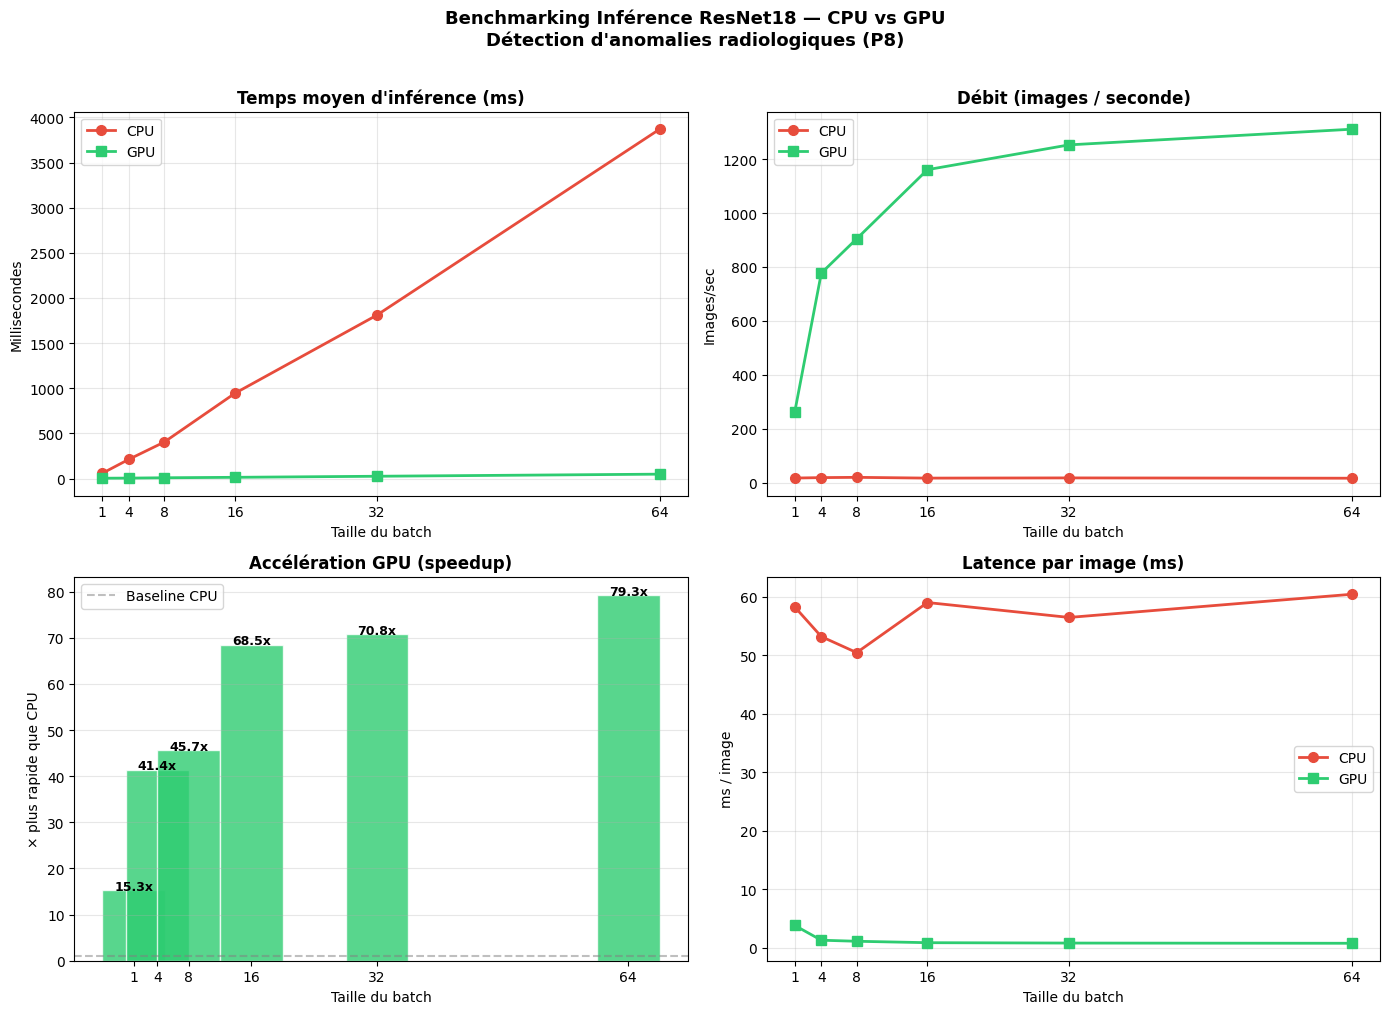


🏆 RÉSUMÉ FINAL
Meilleur speedup GPU : 79.3x (batch=64)
Débit max GPU  : 1311 images/sec
Débit max CPU  : 20 images/sec
Latence min GPU (batch=1) : 3.8ms
Latence min CPU (batch=1) : 58.3ms


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Benchmarking Inférence ResNet18 — CPU vs GPU\nDétection d\'anomalies radiologiques (P8)',
             fontsize=13, fontweight='bold', y=1.01)

clr_cpu = '#E74C3C'
clr_gpu = '#2ECC71'

# 1. Temps moyen par batch
axes[0,0].plot(BATCH_SIZES, df_cpu['avg_ms'],  'o-', color=clr_cpu, lw=2, label='CPU', markersize=7)
axes[0,0].plot(BATCH_SIZES, df_gpu['avg_ms'],  's-', color=clr_gpu, lw=2, label='GPU', markersize=7)
axes[0,0].set_title('Temps moyen d\'inférence (ms)', fontweight='bold')
axes[0,0].set_xlabel('Taille du batch')
axes[0,0].set_ylabel('Millisecondes')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)
axes[0,0].set_xticks(BATCH_SIZES)

# 2. Débit (images/seconde)
axes[0,1].plot(BATCH_SIZES, df_cpu['throughput'], 'o-', color=clr_cpu, lw=2, label='CPU', markersize=7)
axes[0,1].plot(BATCH_SIZES, df_gpu['throughput'], 's-', color=clr_gpu, lw=2, label='GPU', markersize=7)
axes[0,1].set_title('Débit (images / seconde)', fontweight='bold')
axes[0,1].set_xlabel('Taille du batch')
axes[0,1].set_ylabel('Images/sec')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)
axes[0,1].set_xticks(BATCH_SIZES)

# 3. Speedup GPU par batch
speedups = [df_cpu[df_cpu.batch_size==bs]['avg_ms'].values[0] /
            df_gpu[df_gpu.batch_size==bs]['avg_ms'].values[0] for bs in BATCH_SIZES]
bars = axes[1,0].bar(BATCH_SIZES, speedups, color=clr_gpu, alpha=0.8, edgecolor='white', width=8)
axes[1,0].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Baseline CPU')
for bar, sp in zip(bars, speedups):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                   f'{sp:.1f}x', ha='center', fontsize=9, fontweight='bold')
axes[1,0].set_title('Accélération GPU (speedup)', fontweight='bold')
axes[1,0].set_xlabel('Taille du batch')
axes[1,0].set_ylabel('× plus rapide que CPU')
axes[1,0].set_xticks(BATCH_SIZES)
axes[1,0].grid(axis='y', alpha=0.3)
axes[1,0].legend()

# 4. Latence par image
axes[1,1].plot(BATCH_SIZES, df_cpu['latency_per_img'], 'o-', color=clr_cpu, lw=2, label='CPU', markersize=7)
axes[1,1].plot(BATCH_SIZES, df_gpu['latency_per_img'], 's-', color=clr_gpu, lw=2, label='GPU', markersize=7)
axes[1,1].set_title('Latence par image (ms)', fontweight='bold')
axes[1,1].set_xlabel('Taille du batch')
axes[1,1].set_ylabel('ms / image')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)
axes[1,1].set_xticks(BATCH_SIZES)

plt.tight_layout()
plt.savefig('benchmarking_cpu_gpu.png', dpi=150, bbox_inches='tight')
plt.show()

# Résumé final
best_speedup = max(speedups)
best_bs = BATCH_SIZES[speedups.index(best_speedup)]
print(f'\n🏆 RÉSUMÉ FINAL')
print(f'{"="*45}')
print(f'Meilleur speedup GPU : {best_speedup:.1f}x (batch={best_bs})')
print(f'Débit max GPU  : {df_gpu["throughput"].max():.0f} images/sec')
print(f'Débit max CPU  : {df_cpu["throughput"].max():.0f} images/sec')
print(f'Latence min GPU (batch=1) : {df_gpu[df_gpu.batch_size==1]["avg_ms"].values[0]:.1f}ms')
print(f'Latence min CPU (batch=1) : {df_cpu[df_cpu.batch_size==1]["avg_ms"].values[0]:.1f}ms')

## 💾 7. Télécharger les graphiques
Exécutez cette cellule pour télécharger les images générées.

In [ ]:
from google.colab import files
files.download('benchmarking_cpu_gpu.png')
print('✅ Graphique téléchargé !')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Graphique téléchargé !
